<a href="https://colab.research.google.com/github/naldonymous/IMDB-Sentiment-Analysis-Project/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMDB Sentiment Analysis
Install datasets and wordcloud libraries.

In [40]:
!pip install datasets wordcloud

Imports all the required libraries, with "Phases" labelled.

In [41]:
# Phase I
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from wordcloud import WordCloud
# Phase II
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
# Phase III
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

Loads the IMDB dataset, and makes data frames out of pre-labelled "training" and "testing" data.

In [42]:
datasets = load_dataset("imdb")
df_train = pd.DataFrame(datasets["train"])
df_test = pd.DataFrame(datasets["test"])
print(df_train.head())

                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0


Bar graph of amount of positive and negative reviews, amounts seem to be about equal, which is good.

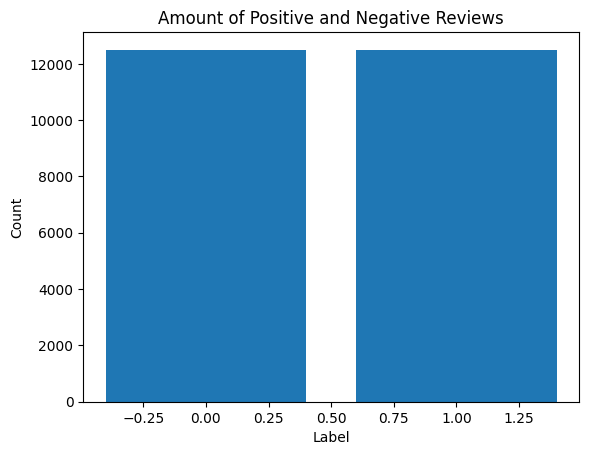

In [43]:
counts = df_train.value_counts('label')
plt.bar(counts.index, counts.values)
plt.title('Amount of Positive and Negative Reviews')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

Histogram of length of reviews. Most seem to be within 0-4000 characters.

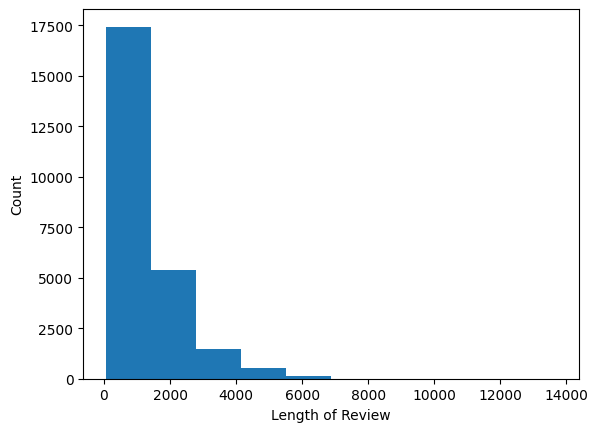

In [44]:
df_train['length'] = df_train['text'].apply(len)

plt.hist(df_train.length)
plt.xlabel('Length of Review')
plt.ylabel('Count')
plt.show()

Makes word clouds for "positive" and "negative" reviews.

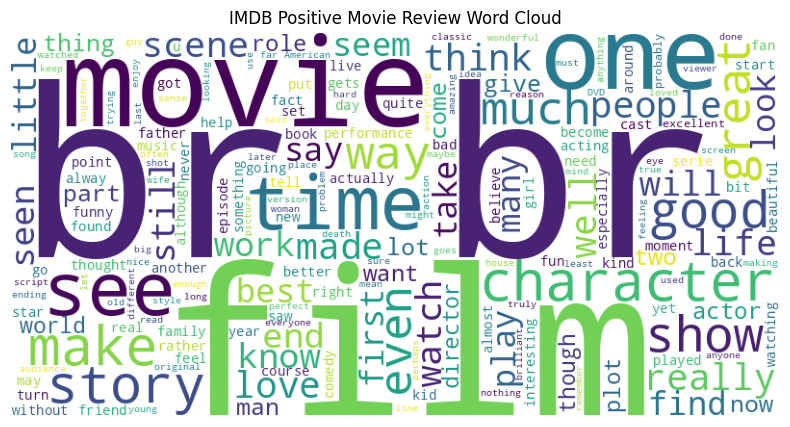

In [45]:
df_tpositive = df_train[df_train['label'] == 1]
df_tnegative = df_train[df_train['label'] == 0]

positive_text = "".join(df_tpositive['text'])
negative_text = "".join(df_tnegative['text'])

positiveWordCloud = WordCloud(width = 800, height = 400, background_color = 'white').generate(positive_text)
plt.figure(figsize=(10, 5))
plt.imshow(positiveWordCloud)
plt.axis('off')
plt.title("IMDB Positive Movie Review Word Cloud")
plt.show()

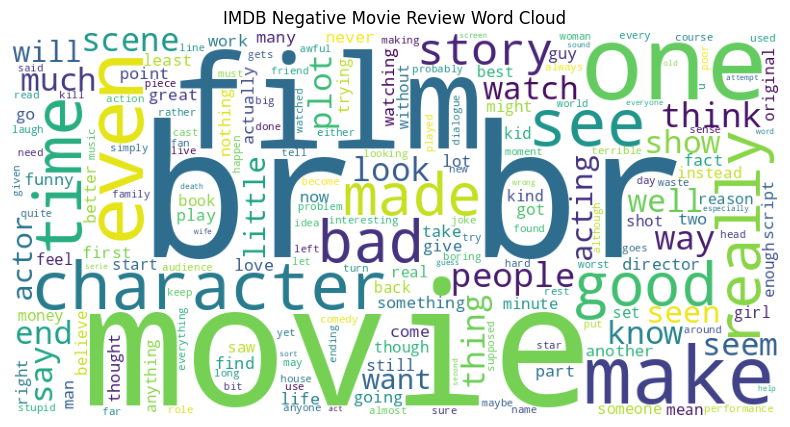

In [46]:
negativeWordCloud = WordCloud(width = 800, height = 400, background_color = 'white').generate(negative_text)
plt.figure(figsize=(10, 5))
plt.imshow(negativeWordCloud)
plt.axis('off')
plt.title("IMDB Negative Movie Review Word Cloud")
plt.show()

Makes training and testing sets.

In [47]:
X_train = df_train['text']
y_train = df_train['label']
X_test = df_test['text']
y_test = df_test['label']

Vectorizes data for fitting later on.

In [48]:
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Logistic regression on data.

In [49]:
logRegression = LogisticRegression()

logRegression.fit(X_train_tfidf, y_train)
y_pred = logRegression.predict(X_test_tfidf)

Finds accuracy score and makes classification report for logistic regression, accuracy is 0.88292.

In [50]:
accuracy_score(y_test, y_pred)

0.88292

In [51]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.88      0.88      0.88     12500\n           1       0.88      0.88      0.88     12500\n\n    accuracy                           0.88     25000\n   macro avg       0.88      0.88      0.88     25000\nweighted avg       0.88      0.88      0.88     25000\n'

Multinomial Naive Bayes on data.

In [52]:
multinomial_model = MultinomialNB()

multinomial_model.fit(X_train_tfidf, y_train)
y_pred_multinomial = multinomial_model.predict(X_test_tfidf)

Linear SVC (Support Vector Classifier) on data.

In [53]:
linear_svc_model = LinearSVC()

linear_svc_model.fit(X_train_tfidf, y_train)
y_pred_linear_svc = linear_svc_model.predict(X_test_tfidf)

Finds accuracy scores for Multinomial Naive Bayes and Linear SVC.

In [54]:
accuracy_score(y_test, y_pred_multinomial)

0.82956

In [55]:
accuracy_score(y_test, y_pred_linear_svc)

0.8772

In [56]:
param_grid = {"C": [0.01, 0.1, 1, 10, 100]}

In [57]:
gridSearch = GridSearchCV(logRegression, param_grid, cv = 5)
gridSearch.fit(X_train_tfidf, y_train)
gridSearch.best_params_

{'C': 1}

In [58]:
model = LogisticRegression(C=1)
model.fit(X_train_tfidf, y_train)
y_pred_model = model.predict(X_test_tfidf)
accuracy_score(y_test, y_pred_model)

0.88292